<a href="https://colab.research.google.com/github/coderpalak3109-cyber/Product_Demand_Prediction/blob/main/Food_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Collection

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load all files
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
meal_info = pd.read_csv('meal_info.csv')
center_info = pd.read_csv('fulfilment_center_info.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

# Merge meal and center info into both train and test
train = train.merge(meal_info, on='meal_id', how='left')
train = train.merge(center_info, on='center_id', how='left')

test = test.merge(meal_info, on='meal_id', how='left')
test = test.merge(center_info, on='center_id', how='left')

print("\nAfter merge - Train shape:", train.shape)
print("After merge - Test shape:", test.shape)
print("\nTrain sample:")
print(train.head(3))

Train shape: (456548, 9)
Test shape: (32573, 8)

Train columns: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']
Test columns: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']

After merge - Train shape: (456548, 15)
After merge - Test shape: (32573, 14)

Train sample:
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   

   emailer_for_promotion  homepage_featured  num_orders   category cuisine  \
0                      0                  0         177  Beverages    Thai   
1                      0                  0         270  Beverages    Thai   
2                      0                  0         189  Beverages    Tha

# Data Pre-procssing

=== Missing Values in Train ===
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

=== Missing Values in Test ===
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

=== Data Types ===
id                         int64
week                       int64
center_id                  int64
meal_id 

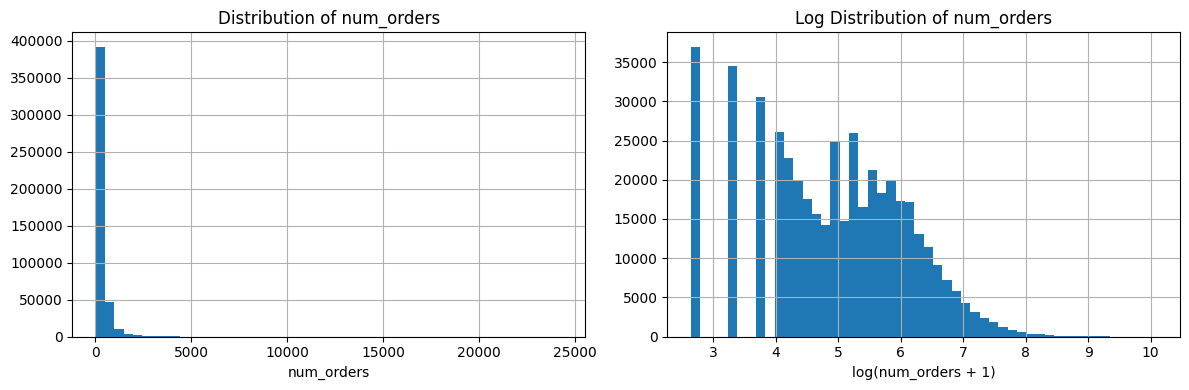


Unique values:
category: 14
cuisine: 4
center_type: 3


In [3]:
# ---- 2a. Check for missing values ----
print("=== Missing Values in Train ===")
print(train.isnull().sum())
print("\n=== Missing Values in Test ===")
print(test.isnull().sum())

# ---- 2b. Check data types ----
print("\n=== Data Types ===")
print(train.dtypes)

# ---- 2c. Basic statistics ----
print("\n=== Target Variable Stats ===")
print(train['num_orders'].describe())

# ---- 2d. Check for outliers in target ----
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
train['num_orders'].hist(bins=50)
plt.title('Distribution of num_orders')
plt.xlabel('num_orders')

plt.subplot(1,2,2)
np.log1p(train['num_orders']).hist(bins=50)
plt.title('Log Distribution of num_orders')
plt.xlabel('log(num_orders + 1)')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

# The target is right-skewed — we will log-transform it for modeling
# log1p(x) = log(x+1), handles zero values safely

train['log_orders'] = np.log1p(train['num_orders'])

# ---- 2e. Encode categorical columns ----
# category and cuisine are text — convert to category codes
for col in ['category', 'cuisine', 'center_type']:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

print("\nUnique values:")
print("category:", train['category'].nunique())
print("cuisine:", train['cuisine'].nunique())
print("center_type:", train['center_type'].nunique())

#  Feature Extraction and Selection

In [4]:
# Sort data — critical for lag features
train = train.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)
test = test.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

# ---- 3a. Price discount feature ----
# How much discount is being offered?
train['discount'] = (train['base_price'] - train['checkout_price']) / train['base_price']
test['discount'] = (test['base_price'] - test['checkout_price']) / test['base_price']

# ---- 3b. Lag features (past orders for same center+meal) ----
# These are the most powerful features for time series forecasting
# We combine train + test to compute lags across the full timeline

full_data = pd.concat([train, test], sort=False)
full_data = full_data.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

# Group by center+meal combination
group = full_data.groupby(['center_id', 'meal_id'])

# Lag 1: orders from 1 week ago
full_data['lag_1'] = group['num_orders'].shift(1)
# Lag 2: orders from 2 weeks ago
full_data['lag_2'] = group['num_orders'].shift(2)
# Lag 3: orders from 3 weeks ago
full_data['lag_3'] = group['num_orders'].shift(3)

# Rolling mean: average of last 3 weeks
full_data['rolling_mean_3'] = group['num_orders'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# Rolling mean: average of last 5 weeks
full_data['rolling_mean_5'] = group['num_orders'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

# Rolling std: variability over last 3 weeks
full_data['rolling_std_3'] = group['num_orders'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).std()
)

# ---- 3c. Week-based features ----
full_data['week_mod_4'] = full_data['week'] % 4   # rough monthly cycle
full_data['week_mod_13'] = full_data['week'] % 13  # rough quarterly cycle

# ---- 3d. Encode categoricals as numbers ----
for col in ['category', 'cuisine', 'center_type']:
    full_data[col] = full_data[col].astype('category').cat.codes

# ---- 3e. Split back into train and test ----
train_fe = full_data[full_data['week'] <= 145].copy()
test_fe  = full_data[full_data['week'] > 145].copy()

print("Train with features shape:", train_fe.shape)
print("Test with features shape:", test_fe.shape)

# ---- 3f. Define features to use ----
FEATURES = [
    'week', 'center_id', 'meal_id',
    'checkout_price', 'base_price', 'discount',
    'emailer_for_promotion', 'homepage_featured',
    'category', 'cuisine',
    'city_code', 'region_code', 'center_type', 'op_area',
    'lag_1', 'lag_2', 'lag_3',
    'rolling_mean_3', 'rolling_mean_5', 'rolling_std_3',
    'week_mod_4', 'week_mod_13'
]

TARGET = 'log_orders'  # log-transformed target

# Drop rows where lag features are NaN (first few weeks per group)
train_clean = train_fe.dropna(subset=['lag_1', 'lag_2', 'lag_3'])
print(f"\nRows after dropping NaN lags: {len(train_clean)} (removed {len(train_fe) - len(train_clean)})")

Train with features shape: (456548, 25)
Test with features shape: (32573, 25)

Rows after dropping NaN lags: 445763 (removed 10785)
